<a href="https://colab.research.google.com/github/jbeeksieu2023-del/ML-fundamentals-2026/blob/main/assignment_1_jade_beeksieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GitHub repository: https://github.com/jbeeksieu2023-del/ML-fundamentals-2026

**Task: Identifying the Prediction Target
Lecture material: Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection).
• Inspect the dataset and identify which column should be treated as the target variable for this assignment.
• Justify why this column represents the appropriate prediction objective in the context of the marketing
campaign.
• Identify at least two other variables that could superficially appear to be valid targets and explain why they
should not be treated as the prediction objective.**

It is important to first diagnose the business problem, to define a goal for our model. This means that we find the **right** solution to the goal.

**"Given client and campaign information available at the time of contact, predict whether
the client subscribes to a term deposit (i.e., a type of short-term investment)."**


From our business problem formulated above, our target variable wil be the column names "y".
This column answers booleanly, yes/no, to whether or not the clients have subscribed to a term deposit. This is a clear answer to the business question, and will allow us to predict based on marketing campaigns, its success directly - yes they have commited, no they have not.
Another variable which may appear as a target would be duration of term deposit. This is information related to whether or not subscribed, but is obtained after the subscription and may therefore lead to data leakage issues. Observing the poutcome, the previous campaign results, may appear valid but is not relevant to the current subscribtion outcome and may tamper with the preditability of our model if used as a target.


In [9]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Models and baseline
!pip install scikit-optimize

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay,
)

# Bayesian Optimization
from skopt import BayesSearchCV
sns.set_theme(style="whitegrid")

# Suppress benign sklearn internal warnings
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

In [10]:
def compute_metrics(y_true, y_pred, y_score=None):
    """Return a dict of standard classification metrics.
    y_score: predicted probabilities for the positive class (needed for ROC-AUC).
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    return metrics


def display_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test):
    df = pd.DataFrame({
        "Set": ["Train", "Validation", "Test"],
        "X shape": [X_train.shape, X_val.shape, X_test.shape],
        "y shape": [y_train.shape, y_val.shape, y_test.shape],
    })
    display(df.style.hide(axis="index"))


def display_metrics(name, metrics, decimals=4):
    print(f"\n{name}")
    df = pd.DataFrame([metrics]).round(decimals)
    display(df.style.hide(axis="index"))


def display_model_results(name, best_params, metrics, decimals=4):
    print(f"\n{name} — Best Parameters")
    display(pd.DataFrame([best_params]).style.hide(axis="index"))
    print(f"{name} — Validation Metrics")
    display(pd.DataFrame([metrics]).round(decimals).style.hide(axis="index"))


# Accumulator for the summary table
results_table = []

def add_result(name, split, metrics, best_params=None, notes=None):
    row = {
        "Model": name,
        "Split": split,
        "Accuracy": metrics.get("accuracy"),
        "Precision": metrics.get("precision"),
        "Recall": metrics.get("recall"),
        "F1": metrics.get("f1"),
        "ROC-AUC": metrics.get("roc_auc"),
        "Notes": notes,
    }
    if best_params:
        row["Best Params"] = ", ".join(f"{k}={v}" for k, v in best_params.items())
    else:
        row["Best Params"] = None
    results_table.append(row)


def show_results(sort_by=("Split", "ROC-AUC"), ascending=(True, False), decimals=4):
    df = pd.DataFrame(results_table)
    if df.empty:
        print("results_table is empty.")
        return df
    df_sorted = df.sort_values(list(sort_by), ascending=list(ascending))
    display(df_sorted.round(decimals).style.hide(axis="index"))
    return df_sorted

**Task: Data Loading and Exploration
Lecture material: Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection and EDA).
• Load the dataset into a Pandas DataFrame.
• Inspect the structure of the dataset: number of observations, number of features, data types, and basic
summary statistics.
• Identify which variables are numerical and which are categorical.
Individual Assignment I AI: Machine Learning Foundation
• Analyze the distribution of the target variable and comment on potential class imbalance.
• Detect explicit and implicit missing values (e.g., special categories such as unknown).
• Visualize the distribution of at least:
 –  two numerical variables; and
 –  two categorical variables.
• Identify at least one variable that may require special consideration before modeling (e.g., due to distributional
properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.
Note: Exploratory analysis is not a checklist of plots. Each visualization or statistic should support a specific
observation or hypothesis about the data.**

In [2]:
import pandas

In [32]:
df=pandas.read_csv("bank-additional.csv", sep=";")

In [33]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [34]:
print(f"Number of observations (rows): {df.shape[0]}")
print(f"Number of features (columns): {df.shape[1]}")

Number of observations (rows): 4119
Number of features (columns): 21


In [35]:
print("Data types and non-null counts:")
df.info()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  c

In [36]:
print("Basic summary statistics for numerical columns:")
display(df.describe())

Basic summary statistics for numerical columns:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [37]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


We can gather some basic information about the dataset now. We have 4119 rows and 21 columns. From the columns, we have split them into two data types, numerical and categorial, shown above.

Distribution of target variable 'y':


,count
y,
no,3668
yes,451


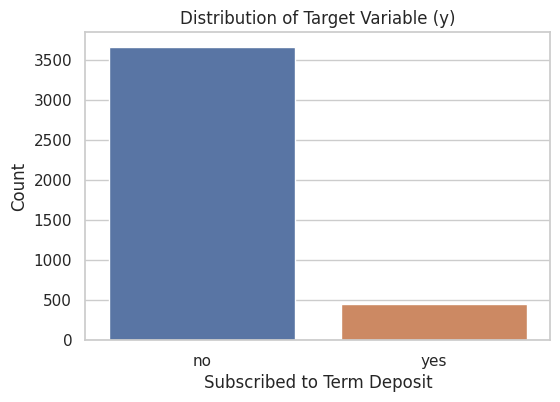


Percentage distribution of 'y':


,proportion
y,
no,89.05074
yes,10.94926


In [44]:
# Distribution of the target variable 'y'
print("Distribution of target variable 'y':")
display(df['y'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, hue='y', legend=False)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

# Check for class imbalance
class_imbalance = df['y'].value_counts(normalize=True) * 100
print("\nPercentage distribution of 'y':")
display(class_imbalance)

In [45]:
# Detect explicit missing values (NaN)
print("Explicit missing values (NaN) per column:")
display(df.isnull().sum())

# Detect implicit missing values (e.g., 'unknown') in categorical columns
print("\nImplicit missing values ('unknown') in categorical columns:")
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].unique():
        print(f"  - Column '{col}': {df[col].value_counts().get('unknown', 0)} occurrences")

Explicit missing values (NaN) per column:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0



Implicit missing values ('unknown') in categorical columns:
  - Column 'job': 39 occurrences
  - Column 'marital': 11 occurrences
  - Column 'education': 167 occurrences
  - Column 'default': 803 occurrences
  - Column 'housing': 105 occurrences
  - Column 'loan': 105 occurrences


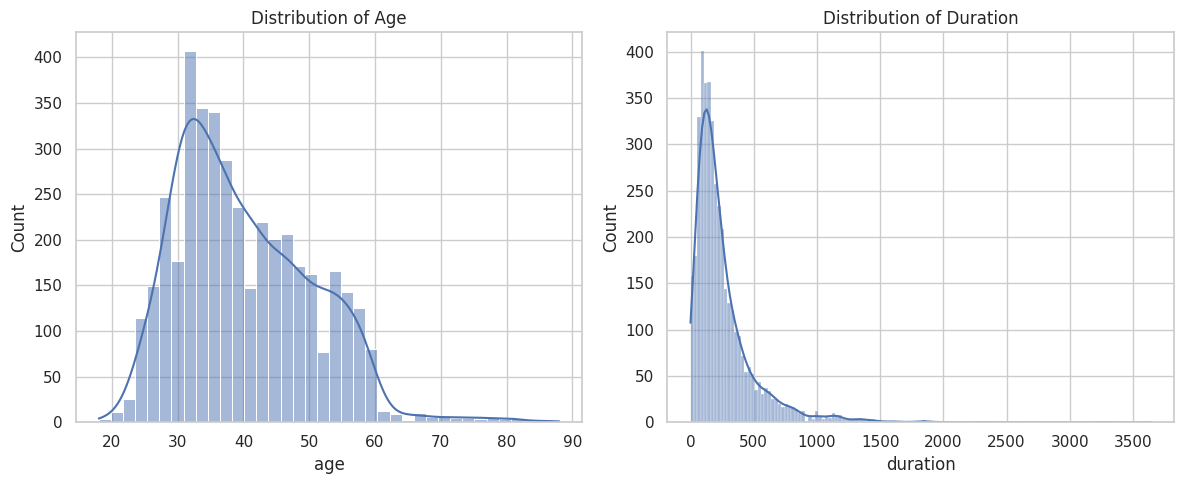

/tmp/ipython-input-1134/790068745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='job', data=df, order=df['job'].value_counts().index, palette='magma')
/tmp/ipython-input-1134/790068745.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='marital', data=df, palette='cividis')


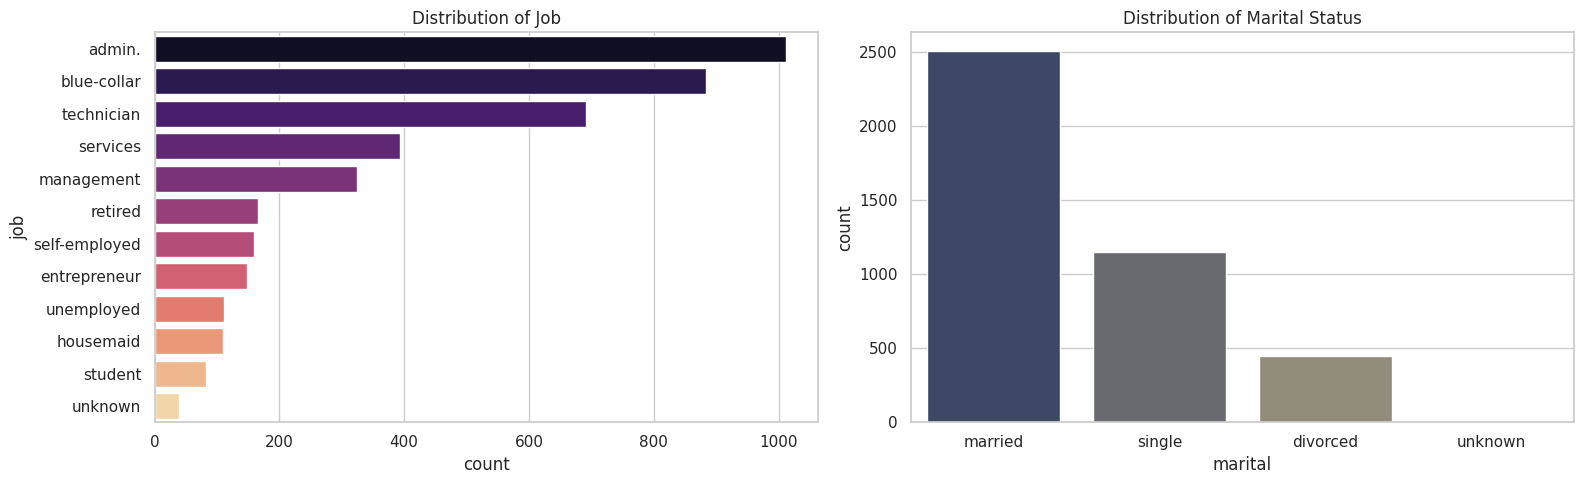

In [46]:
# Visualize distributions of two numerical variables
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 2, 2)
sns.histplot(df['duration'], kde=True)
plt.title('Distribution of Duration')

plt.tight_layout()
plt.show()

# Visualize distributions of two categorical variables
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='job', data=df, order=df['job'].value_counts().index, palette='magma')
plt.title('Distribution of Job')

plt.subplot(1, 2, 2)
sns.countplot(x='marital', data=df, palette='cividis')
plt.title('Distribution of Marital Status')

plt.tight_layout()
plt.show()